## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1. The difference between regression and classification is that regression predicts numeric values that are continuous and classification predicts a category.
2. a Confusion Matrix is a table that compares actual valus to predicted values. It helps us understand what kinds of mistakes the model is making.
3. Accuracy is the number of correct predictions divided by the total predictions. It may not be enought to evaluate a classifier's performance because it can be misleading due to imbalanced datasets.
4. The root mean squared error quanitfies the average size of the prediction error meaning that it tells us how far predictions are from actual values, so lower root mean squared errors mean a better model.
5. Overfitting means that a model is learning the training data too well and it means a high training accuracy with a poor test performance. Underfitting means that the model is too simple and that the real patterns and missed which indicates that there is poor performance on both training and test data.
6. We do this because training data is used to learn the model while the test data is used to evaluate the performance on the new data and so this allows for us to give a realistic estimate on the performance and choose the best model.
7. The strengths for a class label are that they are simple and easy to interpret and we can make direct decisions on them. Weaknesses of the class label are that they do not give us a measure of confidence and they treat uncertain predictions the same as certain ones.Strengths of the predicting proababilites are that they show the model confidence and allows us to choose decision thresholds which are better for risk based descions. Weaknesses would include that they are slightly harder to interpret and require choosing a cutoff to make a final decision.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

fatal: destination path 'scratchpad' already exists and is not an empty directory.


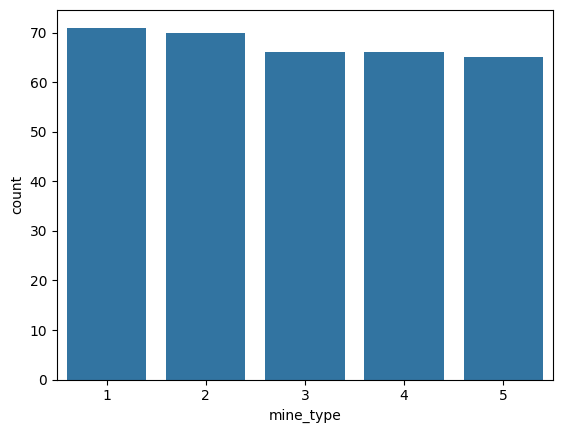

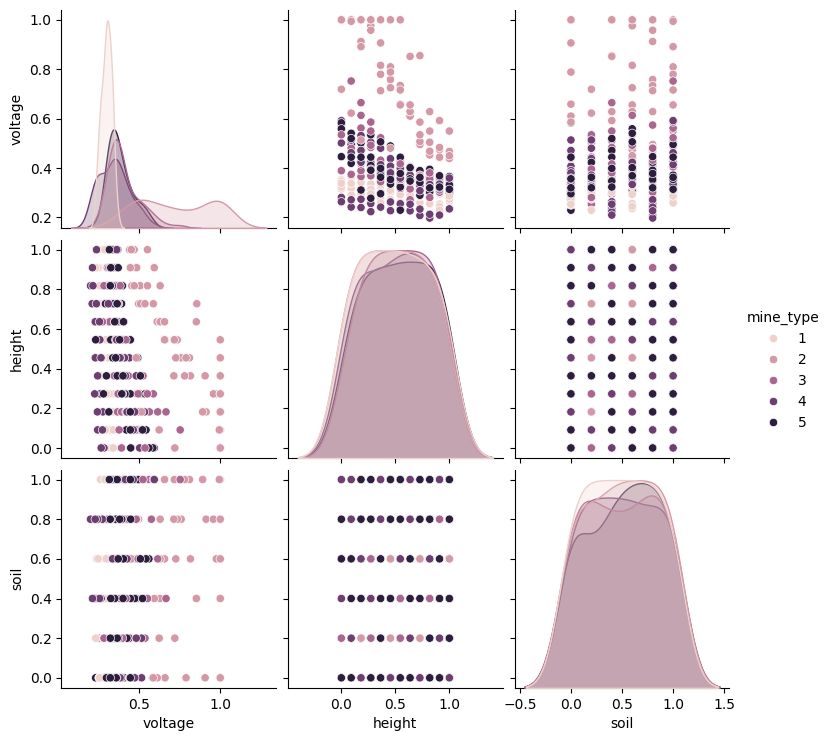

In [24]:
! git clone https://github.com/smerashanmugan/scratchpad
%run ./scratchpad/get_data.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
df = pd.read_csv('/content/data/land_mines.csv', encoding = 'latin1')
df.head()
df['mine_type'].value_counts()
sns.countplot(x='mine_type', data=df)
plt.show()
df.describe()
sns.pairplot(df, hue="mine_type")
plt.show()

In [26]:
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42
)

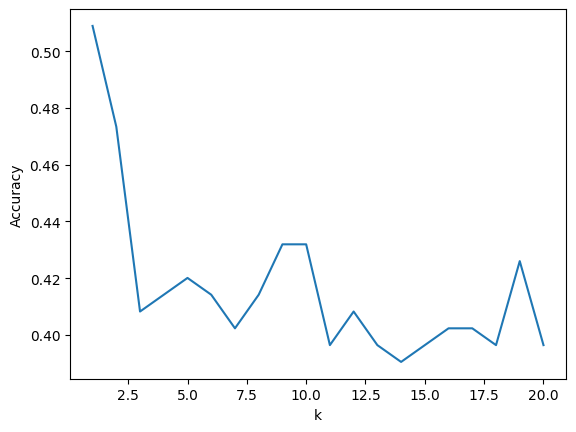

1

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, preds))

plt.plot(k_values, accuracies)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()

best_k = k_values[np.argmax(accuracies)]
best_k

3. You select k by testing multiple values and then choosing the one that produced the highest test accuracy.

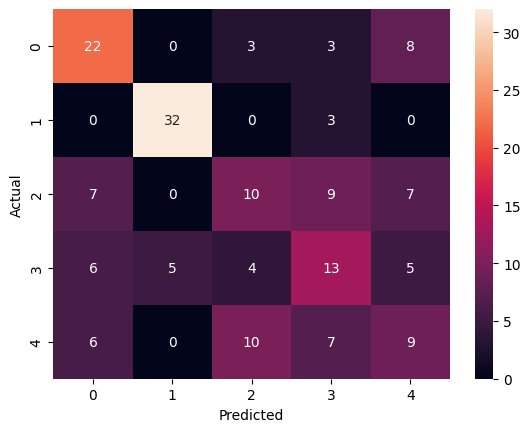

'              precision    recall  f1-score   support\n\n           1       0.54      0.61      0.57        36\n           2       0.86      0.91      0.89        35\n           3       0.37      0.30      0.33        33\n           4       0.37      0.39      0.38        33\n           5       0.31      0.28      0.30        32\n\n    accuracy                           0.51       169\n   macro avg       0.49      0.50      0.49       169\nweighted avg       0.50      0.51      0.50       169\n'

In [28]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
accuracy_score(y_test, y_pred)
classification_report(y_test, y_pred)

4. The overall test accuracy was 51%. It performs well for mine type 2 and mine type 1. Howevere, is performing poorly for mine types 3,4,5.

5. I would recommend using the model above as a decision support tool to prioritize and guide in testing and trustung predictions for mine types that have a higher precision and recall and treating predictions that have frequently confused classes as uncertain and these would require verification before further action is taken.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
df = pd.read_csv("./data/USA_cars_datasets.csv")

df = df[['price', 'year', 'mileage']]

df.head()
df.shape
df.isna().sum()

,0
price,0
year,0
mileage,0


1. There are no missing values.

In [31]:
def maxmin(x):
    return (x - x.min()) / (x.max() - x.min())

df['year'] = maxmin(df['year'])
df['mileage'] = maxmin(df['mileage'])

In [32]:
X = df[['year', 'mileage']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

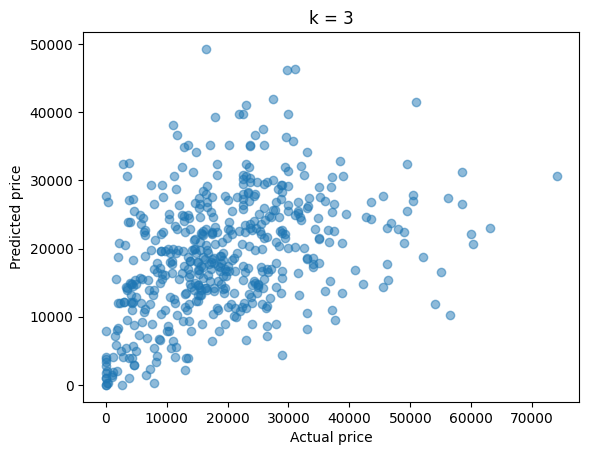

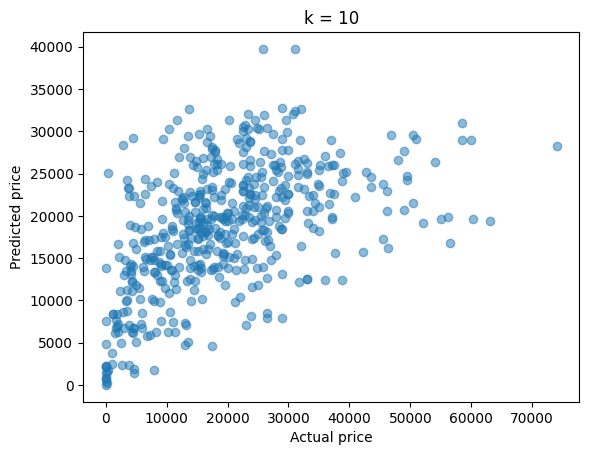

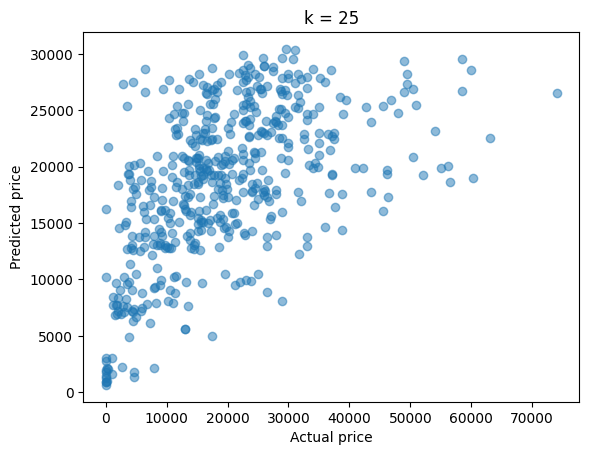

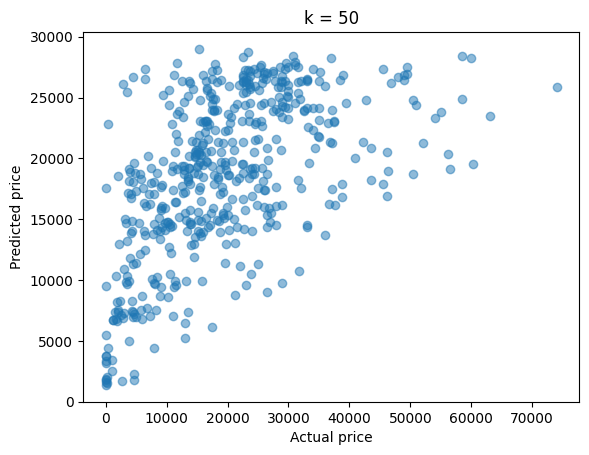

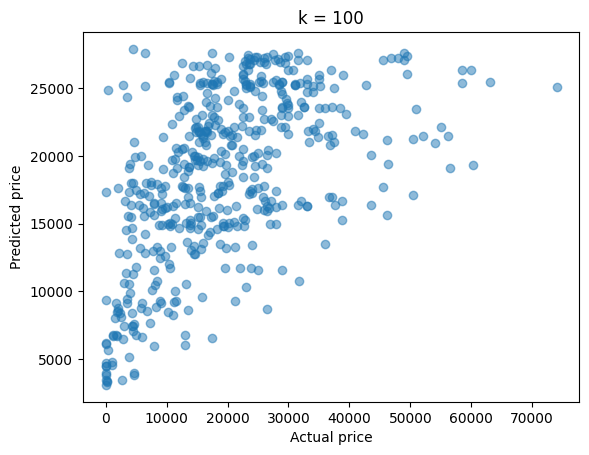

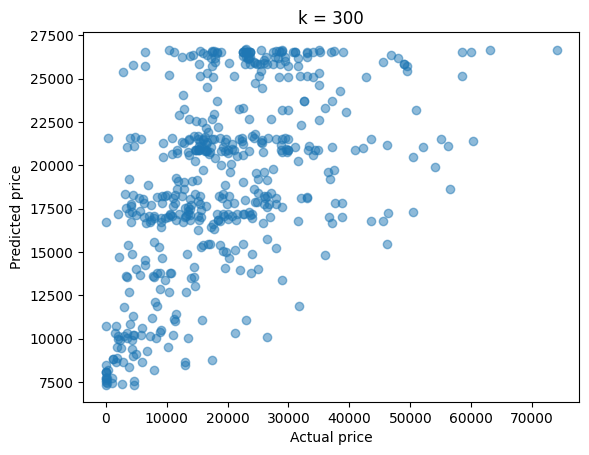

50

In [34]:
k_values = [3, 10, 25, 50, 100, 300]
mse_values = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)

    plt.figure()
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.title(f"k = {k}")
    plt.show()

mse_values
best_k = k_values[np.argmin(mse_values)]
best_k

4. The patterns that I noticed were that for a smaller k, the predictions are more spread out and at a larger k the predictions are clustered in the middle and high prices are too low and low prices are too high.

5. Optimal k is 50 because it minimizes the predition error on data that is not seen.

6. Small k overfits the data because the predictions react too much to random prices nearby and the large k underfits the data because the model looks at too many cars and takes the large average while ignoring the difference between cheap and expensive cars. So the bext k is the middle value as it looks at enough cars to stablize the data but not too many that the data gets averaged out.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
df = pd.read_csv('/content/data/airbnb_hw.csv', encoding = 'latin1' )
df = df.loc[:, ['Review Scores Rating', 'Price', 'Beds']]
df.head()

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
4,96.0,549,3.0


In [40]:
missing = df.loc[df['Review Scores Rating'].isnull(), :]

In [45]:
df = df.dropna(axis=0, how='any')

In [46]:
X = df[['Price', 'Beds']]
y = df['Review Scores Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
k_values = range(1, 26)
mse_values = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mse_values.append(mse)

best_k = k_values[np.argmin(mse_values)]
best_k

23

4. I split the data into training and test sets and tested for the multiple k values. I then chose the K that had the lowest prediction error on the test data.

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('/content/data/airbnb_hw.csv', encoding = 'latin1' )
df = df.loc[:, ['Review Scores Rating', 'Price', 'Beds']]


df['Price'] = df['Price'].astype(str).str.replace(r'[\$,]', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Beds']  = pd.to_numeric(df['Beds'], errors='coerce')

missing = df.loc[df['Review Scores Rating'].isnull(), :].copy()
missing = missing.dropna(subset=['Price', 'Beds'])

df_complete = df.dropna(axis=0, how='any').copy()

print("Missing rows (imputable):", missing.shape[0])
print("Complete rows (trainable):", df_complete.shape[0])

X = df_complete[['Price', 'Beds']]
y = df_complete['Review Scores Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

k_values = range(1, 26)
mse_values = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse_values.append(mean_squared_error(y_test, preds))

best_k = k_values[np.argmin(mse_values)]
print("Best k:", best_k)
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X, y)
if missing.shape[0] > 0:
    X_missing = missing[['Price', 'Beds']]
    missing['Predicted Rating'] = final_model.predict(X_missing)
    print(missing.head())
else:
    print("No imputable missing ratings (missing rows had no Price or Beds).")


Missing rows (imputable): 8282
Complete rows (trainable): 22111
Best k: 23
    Review Scores Rating  Price  Beds  Predicted Rating
0                    NaN    145   1.0         94.521739
1                    NaN     37   1.0         89.478261
2                    NaN     28   1.0         89.260870
3                    NaN    199   3.0         89.565217
13                   NaN     68   1.0         90.478261


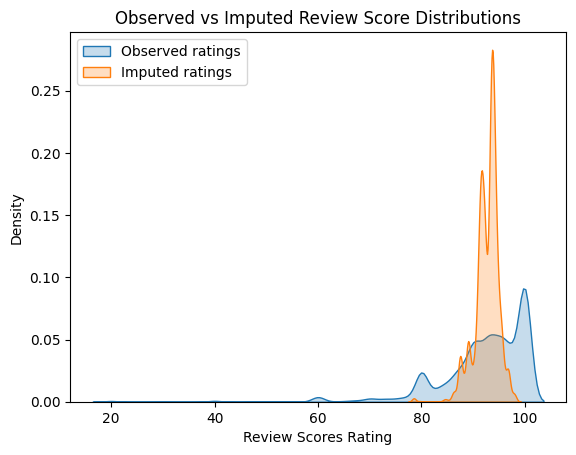

In [55]:
if missing.shape[0] > 0:
    sns.kdeplot(y, label="Observed ratings", fill=True)
    sns.kdeplot(missing['Predicted Rating'], label="Imputed ratings", fill=True)
    plt.legend()
    plt.title("Observed vs Imputed Review Score Distributions")
    plt.show()

6. They do not look similar in shape.The ratings fall in the high score range for both imputed and observed ratings but the distribution of the imputed ratings is much more narrower and has a higher peak.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)